# Which genes respond to dexamethasone in airway smooth muscle cells?

Data: airway, Himes et al. 2014 (GSE52778). 4 cell lines, each once untreated and once treated with dexamethasone.

**Answer:** with only 4 pairs, a per-gene paired t-test finds 1 significant gene, even though known dexamethasone genes like CRISPLD2 go up about 5x. Borrowing spread information across all genes (a moderated t) moves all four known genes up the ranking.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
counts = pd.read_csv("https://bioboot.github.io/bimm143_S20/class-material/airway_scaledcounts.csv", index_col="ensgene")
metadata = pd.read_csv("https://bioboot.github.io/bimm143_S20/class-material/airway_metadata.csv", index_col="id")

In [3]:
counts.shape

(38694, 8)

In [4]:
counts.head()

,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ensgene,,,,,,,,
ENSG00000000003,723.0,486.0,904.0,445.0,1170.0,1097.0,806.0,604.0
ENSG00000000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000419,467.0,523.0,616.0,371.0,582.0,781.0,417.0,509.0
ENSG00000000457,347.0,258.0,364.0,237.0,318.0,447.0,330.0,324.0
ENSG00000000460,96.0,81.0,73.0,66.0,118.0,94.0,102.0,74.0


In [5]:
metadata

,dex,celltype,geo_id
id,,,
SRR1039508,control,N61311,GSM1275862
SRR1039509,treated,N61311,GSM1275863
SRR1039512,control,N052611,GSM1275866
SRR1039513,treated,N052611,GSM1275867
SRR1039516,control,N080611,GSM1275870
SRR1039517,treated,N080611,GSM1275871
SRR1039520,control,N061011,GSM1275874
SRR1039521,treated,N061011,GSM1275875


I think none will be zero in all 8 samples

In [6]:
is_zero = counts == 0
is_zero.head()

,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ensgene,,,,,,,,
ENSG00000000003,False,False,False,False,False,False,False,False
ENSG00000000005,True,True,True,True,True,True,True,True
ENSG00000000419,False,False,False,False,False,False,False,False
ENSG00000000457,False,False,False,False,False,False,False,False
ENSG00000000460,False,False,False,False,False,False,False,False


In [7]:
all_zero = is_zero.all(axis=1)
all_zero.sum()

np.int64(13436)

>13436 are zero in all 8 samples, my prediction was blantantly wrong...

>There are many because not all genes are protein-coding genes, there are also pseudogenes and tissue-specific genes that smooth muscle cells don't use. 

>sd is 0 so t-test divides by zero, gives NaN --> removing them before testing is necessary.


In [8]:
expressed_counts = counts.loc[counts.mean(axis=1) >= 10, :]

In [9]:
expressed_counts.shape

(15285, 8)

>All the fully zero ones are removed, we are left with just over 25000 genes. The cut-off is now bigger so looser. It is not cheating because all zeros where removed, there was no favourability between the control and treated cases. 

>Every cell line is tested against a control of themselves because different cell lines will have different results. This way abnormalities in the cell lines are evened out against the control cases of themselves. 

>We are using a paired t-test here (taking the differences cancels the baseline).

>np.log2(0) will return an error bcause you can't do a number to a power and get 0 

>The log scale will make it so that the higher values are weighted less. 

In [10]:
np.log2(0)

C:\Users\ruben\AppData\Local\Temp\ipykernel_5112\2251961259.py:1: RuntimeWarning: divide by zero encountered in log2
  np.log2(0)


np.float64(-inf)

In [11]:
log_counts = np.log2(expressed_counts+1)

In [12]:
log_counts.min().min()

np.float64(0.0)

In [13]:
np.isinf(log_counts).sum().sum()

np.int64(0)

In [14]:
control_ids = metadata.index[metadata["dex"] == "control"]
trt_ids = metadata.index[metadata["dex"] == "treated"]

In [15]:
pairing = pd.DataFrame({
    "control": metadata.loc[control_ids, "celltype"].values,
    "treated": metadata.loc[trt_ids, "celltype"].values,
})
pairing

,control,treated
0,N61311,N61311
1,N052611,N052611
2,N080611,N080611
3,N061011,N061011


In [16]:
control = log_counts[control_ids]
trt = log_counts[trt_ids]
control.shape, trt.shape

((15285, 4), (15285, 4))

In [17]:
from scipy import stats

t_stat, p_values = stats.ttest_rel(trt, control, axis=1)
p_values = pd.Series(p_values, index=log_counts.index)
(p_values < 0.05).sum()

np.int64(1467)

In [18]:
p_values.isna().sum()

np.int64(0)

In [19]:
p = p_values.dropna()          # BH can't handle NaN
p_arr = p.values               # bare numbers, no gene names

order = np.argsort(p_arr)
m = len(p_arr)
rank = np.arange(1, m + 1)
sorted_p = p_arr[order]
thresholds = (rank / m) * 0.05

passes = sorted_p <= thresholds
k = rank[passes].max()           # same as 03: the highest rank that passes

In [20]:
passing = np.zeros(m, dtype=bool)
passing[order] = rank <= k

significant = pd.Series(passing, index=p.index)   # gene names back on
significant.sum()

np.int64(1)

In [21]:
scipy_passing = stats.false_discovery_control(p_arr) <= 0.05
np.array_equal(passing, scipy_passing)

True

In [22]:
p["ENSG00000103196"], significant["ENSG00000103196"]

(np.float64(0.0041895042817519075), np.False_)

In [23]:
log2fc = pd.Series((trt.values - control.values).mean(axis=1), index=log_counts.index)
log2fc["ENSG00000103196"]

np.float64(2.3922084040890104)

In [24]:
log2fc.rank(ascending=False)["ENSG00000103196"]

np.float64(54.0)

In [25]:
diffs = trt.values - control.values

results = pd.DataFrame({
    "log2fc": log2fc,
    "sd": pd.Series(diffs.std(axis=1, ddof=1), index=log_counts.index),
    "p": p_values,
    "mean_count": expressed_counts.mean(axis=1),
})

results.loc[significant[significant].index].sort_values("p")

,log2fc,sd,p,mean_count
ensgene,,,,
ENSG00000273873,0.820582,0.016607,0.000002,100.75


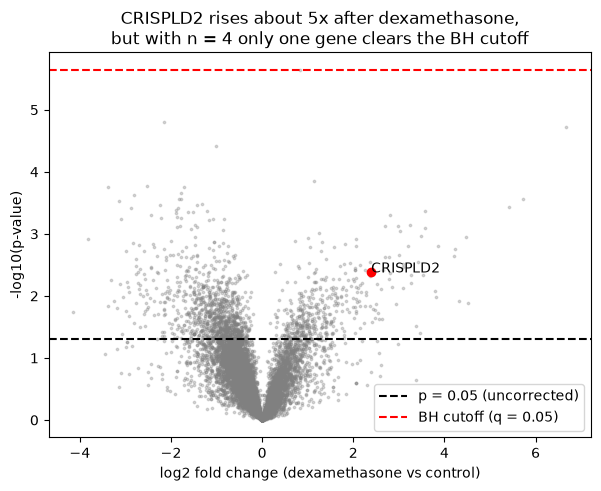

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(results["log2fc"], -np.log10(results["p"]), s=3, alpha=0.3, color="grey")

crisp = results.loc["ENSG00000103196"]
ax.scatter(crisp["log2fc"], -np.log10(crisp["p"]), color="red")
ax.annotate("CRISPLD2", (crisp["log2fc"], -np.log10(crisp["p"])))

ax.axhline(-np.log10(0.05), linestyle="--", color="black", label="p = 0.05 (uncorrected)")

ax.set_xlabel("log2 fold change (dexamethasone vs control)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("CRISPLD2 rises about 5x after dexamethasone,\nbut with n = 4 only one gene clears the BH cutoff")

ax.axhline(-np.log10(sorted_p[k - 1]), linestyle="--", color="red", label="BH cutoff (q = 0.05)")
ax.legend()
plt.show()

In [27]:
sd = results["sd"]
normal_t = log2fc / (sd / np.sqrt(control.shape[1]))
s0 = np.median(sd)
moderated_t = log2fc / ((sd + s0) / np.sqrt(control.shape[1]))
s0

np.float64(0.5212599153568224)

In [28]:
gene = "ENSG00000103196"
normal_t.abs().rank(ascending=False)[gene], moderated_t.abs().rank(ascending=False)[gene]

(np.float64(156.0), np.float64(82.0))

In [29]:
known = ["ENSG00000103196", "ENSG00000096060", "ENSG00000163884", "ENSG00000120129"]
# CRISPLD2, FKBP5, KLF15, DUSP1

In [30]:
for gene in known:
    print(gene)
    print(normal_t.abs().rank(ascending=False)[gene], moderated_t.abs().rank(ascending=False)[gene])

ENSG00000103196
156.0 82.0
ENSG00000096060
68.0 20.0
ENSG00000163884
75.0 18.0
ENSG00000120129
95.0 40.0


## Findings

1. **Filtering.** 13,436 genes are zero in all 8 samples, because the gene list also holds pseudogenes and genes that smooth muscle cells don't use. A first filter removed only those, but 11 of the 15 "significant" genes that came out were genes with about half a read, where all 4 differences were exactly equal: sd = 0, so t = infinite, so p = 0. One read is sequencing noise, not biology, so near-zero genes had to go too. Final filter: mean count >= 10 (a common rule of thumb, not a law), leaving 15,285 genes.

2. **Method.** log2(count + 1): the log turns ratios into differences, so a doubling counts the same at 10 reads as at 1,000 (both +1); the +1 is there because log2(0) is minus infinity. Paired t-test (`ttest_rel`) instead of `ttest_ind`, because each cell line is its own control: the treated-minus-control difference cancels each cell line's own baseline. BH correction written by hand, identical to scipy.

3. **Result.** 1 of 15,285 genes survives BH (q < 0.05). CRISPLD2, the headline gene of the paper, goes up about 5x (log2FC 2.39, p = 0.004) and still fails: in the volcano plot the BH cutoff sits at -log10(p) = 5.65, CRISPLD2 at 2.4. The reason: with 4 pairs, each gene's spread is estimated from 4 numbers, so CRISPLD2's normal biological variation (sd 0.6) gives only a modest t, while BH across 15,285 tests demands p below about 0.000002.

4. **Moderated t.** Adding s0 (the median sd across all genes, 0.52) to each gene's sd gives every gene a floor of s0, so the ones with a small sd don't blow up anymore. Rank by |t|, normal vs moderated:

| Gene | Normal | Moderated |
|---|---|---|
| CRISPLD2 | 156 | 82 |
| FKBP5 | 68 | 20 |
| KLF15 | 75 | 18 |
| DUSP1 | 95 | 40 |

All four known glucocorticoid-response genes climb. This is the idea behind limma and DESeq2: borrow information across all genes instead of trusting each gene's own 4-number spread.

5. **Limits.** n = 4 pairs. The moderated t gives ranks only, no p-values. Data loaded from a course copy (bioboot BIMM143), not straight from GEO.

6. **AI use.** The ID, pairing, t-test, BH skeleton, log2fc, results table and volcano cells were typed from Claude's code (some with blanks to fill), at my request. The answer and the reasons in bullets 1 to 4 were corrected by Claude, also at my request, and so was the volcano plot title. The filters, the moderated-t correction and all predictions are mine.